# Sample statistics

In [1]:
from wilds import *
from datetime import datetime
import pandas as pd
import pytz
import numpy as np

In [2]:
dataset = get_dataset(dataset="fmow", download=False, root_dir="/home/erik/git/bigpicture/data")
metadata = dataset.metadata
split_names = ['train', 'val', 'test', 'id_val', 'id_test']
subsets_indices = [dataset.get_subset(split_name).indices for split_name in split_names]
fmow_wilds_indices = np.concatenate(subsets_indices)
print(len(fmow_wilds_indices))

141696


In [3]:
metadata['timestamp_dt'] = pd.to_datetime(metadata['timestamp'])

utc = pytz.UTC
id_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2002, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2012 + 1, 1, 1)))
ood_val_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2013, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2015 + 1, 1, 1)))
ood_test_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2016, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2017 + 1, 1, 1)))
train_mask = (metadata['split'] == 'train')
val_mask = (metadata['split'] == 'val')
test_mask = (metadata['split'] == 'test')
train_len = len(metadata[id_mask & train_mask])
val_len = len(metadata[ood_val_mask & val_mask])
test_len = len(metadata[ood_test_mask & test_mask])
id_val_len = len(metadata[id_mask & val_mask])
id_test_len = len(metadata[id_mask & test_mask])
print(train_len, val_len, test_len, id_val_len, id_test_len)
print(train_len + val_len + test_len + id_val_len + id_test_len)

76863 19915 22108 11483 11327
141696


# Compute the time span of the fMoW WILDS dataset

In [5]:
import pandas as pd
df = pd.read_csv(
    "~/git/bigpicture/data/fmow_v1.1/rgb_metadata.csv",
    parse_dates=["timestamp"],
    date_format="%Y-%m-%dT%H:%M:%SZ"
) 

print(
    df["timestamp"].min(), 
    df["timestamp"].max() 
)

2002-01-28 07:04:18 2017-07-12 08:25:25


# Show image spans of FMoW WILDS dataset and compute resolution

In [6]:
import pandas as pd
df = pd.read_csv(
    "/home/erik/git/bigpicture/data/fmow_landsat/rgb_metadata_extended.csv"
    )

In [7]:
min_span = df["img_span_km"].min()
max_span = df["img_span_km"].max()
max_res = min_span * 1000 / 224
min_res = max_span * 1000 / 224

print(f"Max resolution = {max_res:.2f} m/px with {max_span} km span. The HR would be represented by {max_res * 224 / 30:.2f} px at 30 m/px resolution.")
print(f"Min resolution = {min_res:.2f} m/px with {min_span} km span. The HR would be represented by {min_res * 224 / 30:.2f} px at 30 m/px resolution.")

print(f"Relation between the scales ranges between {30 / max_res:.2f} and {30 / min_res:.2f}.")

Max resolution = 0.61 m/px with 4.982763570862209 km span. The HR would be represented by 4.54 px at 30 m/px resolution.
Min resolution = 22.24 m/px with 0.1363199163954886 km span. The HR would be represented by 166.09 px at 30 m/px resolution.
Relation between the scales ranges between 49.30 and 1.35.


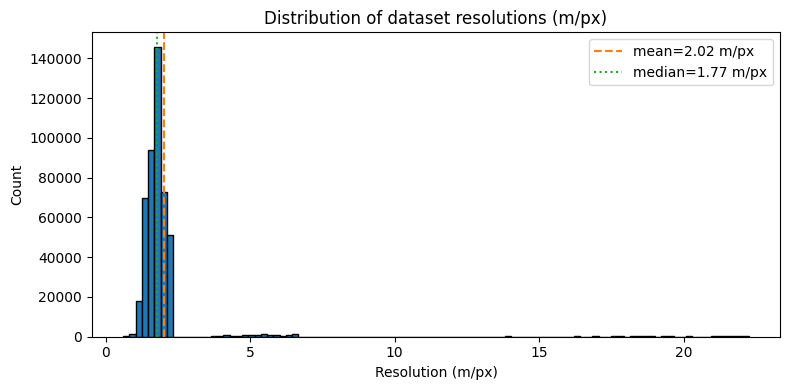

In [8]:
import matplotlib.pyplot as plt

res_mpx = df["img_span_km"].dropna() * 1000 / 224

plt.figure(figsize=(8,4))
plt.hist(res_mpx, bins=100, color='C0', edgecolor='k')
plt.axvline(res_mpx.mean(), color='C1', linestyle='--', label=f"mean={res_mpx.mean():.2f} m/px")
plt.axvline(res_mpx.median(), color='C2', linestyle=':', label=f"median={res_mpx.median():.2f} m/px")
plt.xlabel("Resolution (m/px)")
plt.ylabel("Count")
plt.title("Distribution of dataset resolutions (m/px)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
lr_image_size = 4.982763570862209 * 3 / 30 * 1000
lr_res = lr_image_size / 224 * 30
print(f"LR image size = {lr_image_size:.2f} px. LR has a resolution of {lr_res:.2f} m/px.")

LR image size = 498.28 px. LR has a resolution of 66.73 m/px.
